In [5]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# DenseNet compositions

def conv_block(
    num_channels: int,
) -> nn.Sequential:

    return nn.Sequential(
        nn.LazyBatchNorm2d(),
        nn.ReLU(),
        nn.LazyConv2d(
            out_channels=num_channels,
            kernel_size=3, # 3x3 Conv
            padding=1,     # Spatial shape 유지
        ),
    )


class DenseBlock(nn.Module):

    def __init__(
        self,
        num_convs: int,
        num_channels: int,
    ) -> None:
        super().__init__()

        layers: list[nn.Module] = []

        for _ in range(num_convs):
            layers.append(
                conv_block(num_channels)
            )

        self.net = nn.Sequential(
            *layers,
        )


    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:

        for block in self.net:
            Y: torch.Tensor = block(X)

            # Channel axis로 concatenate
            X = torch.cat(
                (X, Y),
                dim=1,
            )

        return X


def transition_block(
    num_channels: int,
) -> nn.Sequential:

    return nn.Sequential(
        nn.LazyBatchNorm2d(),
        nn.ReLU(),
        
        # 1x1 Conv로 output channel 압축
        nn.LazyConv2d(
            out_channels=num_channels,
            kernel_size=1,
        ),
        
        # spatial shape: H, W 축소
        nn.AvgPool2d(
            kernel_size=2,
            stride=2,
        ),
    )

In [ ]:
# DenseNet Architecture: 
# - input과 output을 channel dimension을 따라 concatenation

# Input
# -> Stem: 7×7 Conv → BN → ReLU → MaxPool
# -> Dense Block 1 → Transition 1
# -> Dense Block 2 → Transition 2
# -> Dense Block 3 → Transition 3
# -> Dense Block 4
# -> BN → ReLU → Global Average Pooling
# -> Flatten → Linear
# -> 10 logits

class DenseNet(d2l.Classifier):
    
    @staticmethod
    def stem() -> nn.Sequential:
        return nn.Sequential(
            nn.LazyConv2d(
                out_channels=64,
                kernel_size=7,
                stride=2,
                padding=3,
            ),
            nn.LazyBatchNorm2d(),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1,
            ),
        )
    
    def __init__(
        self,
        num_channels: int = 64,
        growth_rate: int = 32,
        
        # 각 Dense Block의 Convolution Layer 수
        arch: tuple[int, ...] = (
            4, # Dense Block 1
            4, # Dense Block 2
            4, # Dense Block 3
            4, # Dense Block 4
        ),
        
        lr: float = 0.1,
        num_classes: int = 10,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()
        
        self.net = nn.Sequential(
            self.stem(),
        )
        
        for index, num_convs in enumerate(
            arch
        ):
            self.net.add_module(
                f"dense_block_{index + 1}",
                DenseBlock(
                    num_convs=num_convs,
                    num_channels=growth_rate,
                ),
            )
            
            # [Dense Block]
            # - Channel 누적
            # - Spatial shape 유지
            num_channels += (
                num_convs * growth_rate
            )
            
            # [Transition Block] (마지막 제외)
            # - Channel 반갈죽
            # - output shape 반갈죽
            if index != len(arch) - 1:
                
                num_channels //= 2

                self.net.add_module(
                    f"transition_block_{index + 1}",
                    transition_block(
                        num_channels=num_channels,
                    ),
                )
                
                
        self.net.add_module(
            "head",
            nn.Sequential(
                nn.LazyBatchNorm2d(),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d(
                    output_size=(1, 1),
                ),
                nn.Flatten(),
                nn.LazyLinear(
                    out_features=num_classes,
                ),
            ),
        )

In [8]:
# Tensor Shape & Parameter 체크

model = DenseNet()

sample_input = torch.randn(
    1,
    1,
    96,
    96,
)

model.apply_init(
    [sample_input],
    d2l.init_cnn,
)

X: torch.Tensor = sample_input

with torch.no_grad():
    for name, layer in model.net.named_children():
        X = layer(X)

        print(
            f"{name:<20}",
            "output shape:",
            tuple(X.shape),
        )

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "\nParameter count:",
    f"{parameter_count:,}",
)

0                    output shape: (1, 64, 24, 24)
dense_block_1        output shape: (1, 192, 24, 24)
transition_block_1   output shape: (1, 96, 12, 12)
dense_block_2        output shape: (1, 224, 12, 12)
transition_block_2   output shape: (1, 112, 6, 6)
dense_block_3        output shape: (1, 240, 6, 6)
transition_block_3   output shape: (1, 120, 3, 3)
dense_block_4        output shape: (1, 248, 3, 3)
head                 output shape: (1, 10)

Parameter count: 758,226


In [9]:
# Training Device Check

cuda_available = torch.cuda.is_available()

num_gpus = (
    1
    if cuda_available
    else 0
)

training_device = torch.device(
    "cuda"
    if cuda_available
    else "cpu"
)

print(
    "Device:",
    training_device,
)

if cuda_available:
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


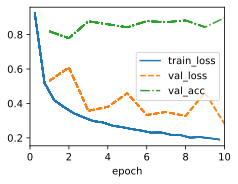

In [10]:
# Fashion-MNIST Training

data = d2l.FashionMNIST(
    batch_size=128,
    resize=(96, 96),
)

model = DenseNet(
    lr=1e-2,
)

sample_input = torch.randn(
    1,
    1,
    96,
    96,
)

model.apply_init(
    [sample_input],
    d2l.init_cnn,
)

trainer = d2l.Trainer(
    max_epochs=10,
    num_gpus=num_gpus,
)

trainer.fit(
    model,
    data,
)